# Anomaly Detection Pipeline

This notebook walks through detecting suspicious login activity in cybersecurity logs. The goal is to separate normal user behavior from likely attack attempts using simple features like time of day, failed login counts, session duration, and protocol used.

The pipeline below proceeds in stages: setup → exploratory data analysis (EDA) → modeling. We start by installing the required libraries and importing them.

---

In [1]:
%pip install seaborn
%pip install matplotlib
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report



from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

## 1. EDA   



### 1.1 Load the dataset

We read `cybersecurity_logs.csv` into a pandas DataFrame. Each row represents a single login event, and the columns describe its context:

- `hour` — hour of day the login happened (0–23)
- `failed_attempts` — number of failed logins before this one
- `login_duration` — session length in seconds
- `protocol` — protocol used (HTTP, HTTPS, etc.)
- `label` — ground truth: `0` = normal, `1` = attack attempt

A quick `head()` lets us sanity-check the schema before going further.



In [3]:
df = pd.read_csv('cybersecurity_logs.csv')
print(df.head())



   hour  failed_attempts  login_duration protocol  label
0    15                1      323.722652    HTTPS      0
1     6                0      120.217590     HTTP      0
2    10                2      183.137990    HTTPS      0
3     9                1      129.783328     HTTP      0
4    15                0      287.132365    HTTPS      0


### 1.2 Inspect the class balance

Before any modeling we need to know how skewed the data is. We replace the numeric labels with readable names (`Normal`, `Attack Attempt`) and look at the proportions.

In real-world security data, attacks are rare events — and this dataset reflects that, with attacks making up only ~3% of all logins. This imbalance matters: a naive classifier could reach 97% accuracy by always predicting "Normal" while catching zero attacks. We'll need to keep this in mind when choosing models and metrics.



In [9]:
label_map = {0: 'Normal', 1: 'Attack Attempt'}
df['label'] = df['label'].map(label_map)

print(f"Shape: {df.shape}")
print(f"\nClass Distribution:\n{df['label'].value_counts(normalize=True) * 100}")

Shape: (10000, 5)

Class Distribution:
label
Normal            97.0
Attack Attempt     3.0
Name: proportion, dtype: float64


### 1.3 Visualize the class distribution

A quick count plot makes the imbalance visually obvious. The "Normal" bar towers over "Attack Attempt", which reinforces why standard accuracy is misleading here and why we'll want to look at precision, recall, and F1 once we get to evaluation.


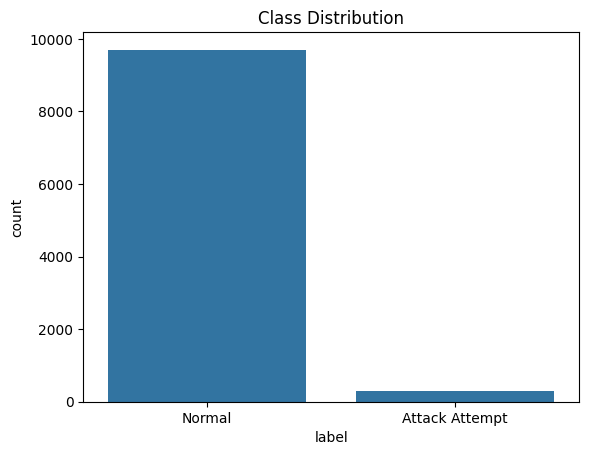

In [10]:
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.show()


### 1.4 Activity pattern by hour of day

A KDE plot lets us compare *when* normal users log in versus when attack attempts occur. Normal traffic typically peaks during business hours, while automated or malicious activity tends to cluster at unusual times — late nights and early mornings.

If the two distributions separate cleanly, `hour` is likely to be a useful feature for the model.



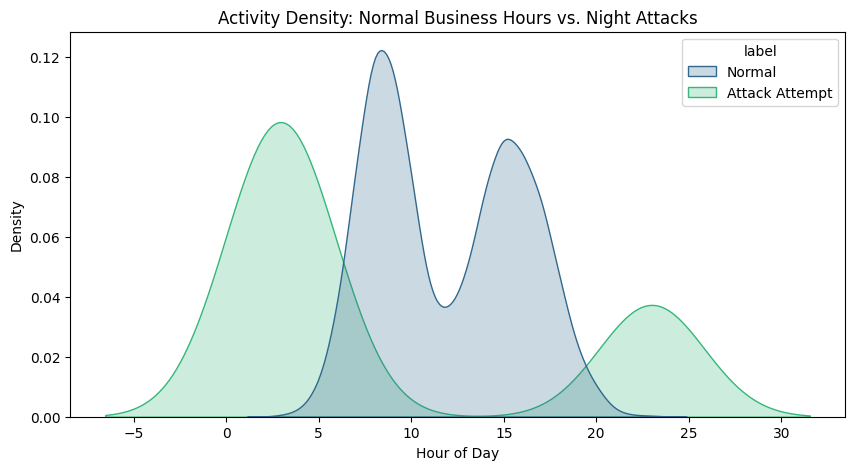

In [12]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='hour', hue='label', fill=True, common_norm=False, palette='viridis')
plt.title('Activity Density: Normal Business Hours vs. Night Attacks')
plt.xlabel('Hour of Day')
plt.show()

### 1.5 Protocol usage by class

Different protocols may carry different risk profiles — for example, attackers may favor older or unencrypted protocols. We compare the mix of protocols used by normal vs. attack logins.

Because the attack class is so much smaller, we plot on a **log scale** so the rare attack counts remain visible alongside the much larger normal counts. Otherwise the attack bars would barely register.



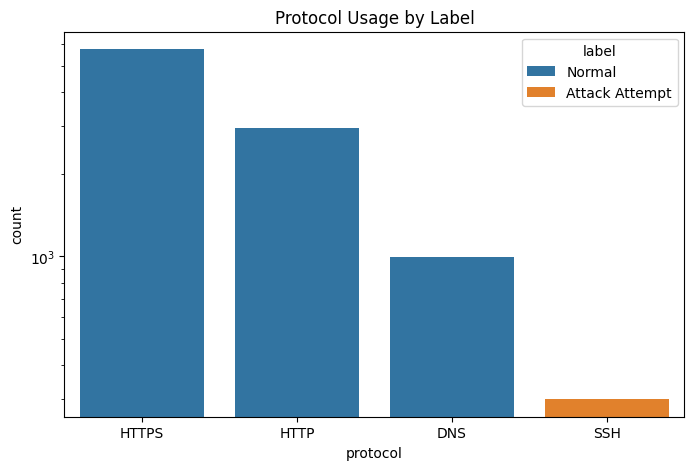

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='protocol', hue='label')
plt.title('Protocol Usage by Label')
plt.yscale('log') # Log scale helps see the small anomaly counts
plt.show()

## 2. Modeling — Isolation Forest

With EDA done, we move on to detecting anomalies. We use **Isolation Forest**, an unsupervised model well-suited to highly imbalanced data like ours: instead of learning what "attack" looks like, it learns what *normal* looks like and flags everything that doesn't fit.




              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9700
           1       1.00      1.00      1.00       300

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



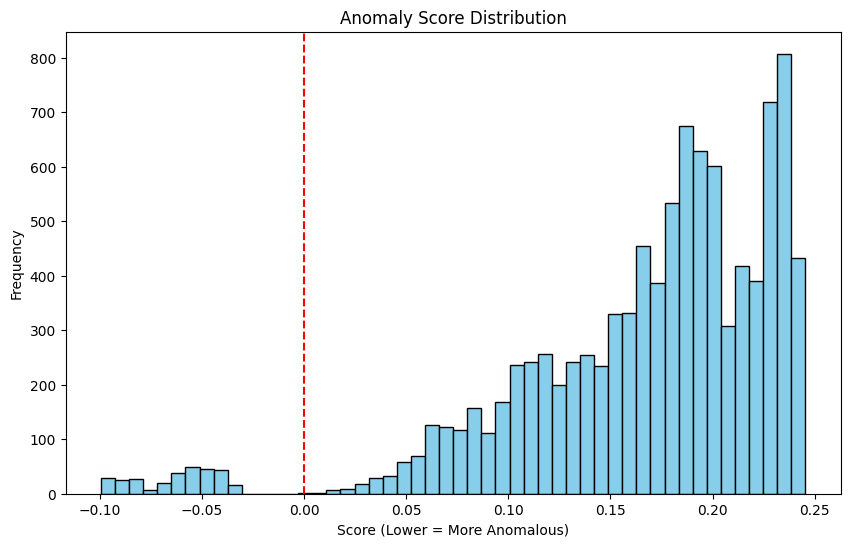

In [15]:


df = pd.read_csv('cybersecurity_logs.csv')

X = pd.get_dummies(df.drop(columns=['label']), columns=['protocol'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(contamination=0.03, random_state=42)
model.fit(X_scaled)

df['anomaly_score'] = model.decision_function(X_scaled)
df['prediction'] = model.predict(X_scaled)
df['prediction'] = df['prediction'].map({1: 0, -1: 1})

print(classification_report(df['label'], df['prediction']))

plt.figure(figsize=(10, 6))
plt.hist(df['anomaly_score'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Anomaly Score Distribution')
plt.xlabel('Score (Lower = More Anomalous)')
plt.ylabel('Frequency')
plt.show()

### What the histogram is telling us

Each bar shows **how many login events got a given anomaly score**.

- **Right side (high scores):** the big mountain of bars. These are normal logins — the model is confident they look like everyday traffic.
- **Left side (low scores):** the small tail. These are the suspicious ones — logins that don't fit the normal pattern.
- **Red dashed line at 0:** the cutoff. Anything to the **left** of the line is flagged as an attack; anything to the **right** is treated as normal.

In short: most logins pile up on the right (normal), and a small group leaks out to the left (attacks). The further left a point sits, the more unusual it is.

## 3. Visualizing the anomalies in 2D (PCA)

The histogram tells us *how many* anomalies the model flagged, but not *where* they sit relative to the normal points. Our feature space has several dimensions (`hour`, `failed_attempts`, `login_duration`, plus one column per protocol after one-hot encoding), so we can't plot it directly.

**PCA (Principal Component Analysis)** compresses those dimensions down to just two while preserving as much of the structure as possible. The two new axes (`PC1`, `PC2`) are linear combinations of the original features and give us a flat picture we can actually look at.

We then color each point by the model's prediction:

- **Blue** = predicted Normal
- **Red** = predicted Anomaly

This lets us visually check whether the anomalies cluster apart from the normal traffic — a good sign that the model is picking up on real structure in the data, not random noise.

---

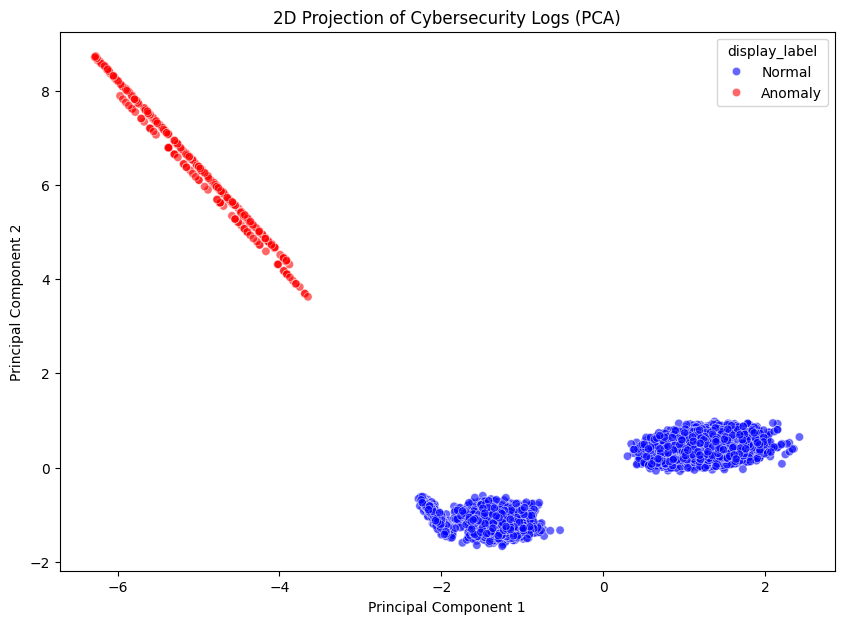

In [18]:


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

df['display_label'] = df['prediction'].map({0: 'Normal', 1: 'Anomaly'})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df, 
    x='pca1', 
    y='pca2', 
    hue='display_label', 
    palette={'Normal': 'blue', 'Anomaly': 'red'},
    alpha=0.6
)
plt.title('2D Projection of Cybersecurity Logs (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### What the scatter plot is telling us

Each dot is a single login event, projected down to two dimensions:

- **Blue dots** are the bulk of the data — normal logins forming a dense central cloud.
- **Red dots** are the events Isolation Forest flagged as anomalies. They tend to sit on the **edges** of the cloud or in their own little pockets, away from the dense center.

The takeaway: if the red points were scattered randomly *inside* the blue cloud, the model would basically be guessing. The fact that they sit at the **boundaries** — the unusual corners of the feature space — suggests the model is genuinely separating "weird" logins from "typical" ones, which is exactly what anomaly detection should do.